# Evaluation


In [ ]:
def count_matches(pred_boxes, gt_boxes, iou_thresh=0.50):
    """One prediction can match only one ground-truth box."""
    tp = 0
    matched = set()
    for pb in pred_boxes:
        best_iou, best_j = 0, -1
        for j, gb in enumerate(gt_boxes):
            if j in matched:
                continue
            v = box_iou(pb, gb)
            if v > best_iou:
                best_iou, best_j = v, j
        if best_iou >= iou_thresh and best_j >= 0:
            tp += 1
            matched.add(best_j)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - len(matched)
    return tp, fp, fn


def prf(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0
    r = tp / (tp + fn) if tp + fn else 0
    f = 2 * p * r / (p + r) if p + r else 0
    return p, r, f


In [ ]:
all_ious = []
yolo_tp = yolo_fp = yolo_fn = 0
ens_tp = ens_fp = ens_fn = 0
total_yolo_det = 0
total_veto_count = 0
veto_reason_counts = {}
per_image_rows = []

for i, res in enumerate(all_results):
    label_path = processed_dataset_dir / "val" / "labels" / (val_fused_paths[i].stem + ".txt")
    gt_boxes = load_gt(label_path, TARGET_RES)

    yolo_boxes = res["yolo_boxes_xyxy"].tolist()

    # For detection metrics, the ensemble keeps the original YOLO box
    # whenever its SAM mask survives validation.
    surviving_indices = []
    for box_index, _ in enumerate(res["final_masks"]):
        if box_index < len(yolo_boxes):
            surviving_indices.append(box_index)

    ensemble_boxes = [yolo_boxes[i] for i in surviving_indices]
    mask_boxes = [box for box in res["final_mask_boxes_xyxy"] if box is not None]

    y_tp, y_fp, y_fn = count_matches(yolo_boxes, gt_boxes)
    e_tp, e_fp, e_fn = count_matches(ensemble_boxes, gt_boxes)

    yolo_tp += y_tp; yolo_fp += y_fp; yolo_fn += y_fn
    ens_tp += e_tp; ens_fp += e_fp; ens_fn += e_fn
    total_yolo_det += len(yolo_boxes)
    total_veto_count += res["vetoed"]

    for reason in res["veto_reasons"]:
        veto_reason_counts[reason] = veto_reason_counts.get(reason, 0) + 1

    # Proxy mIoU still uses the SAM mask boxes, this is about mask localization.
    for pred_box in mask_boxes:
        if gt_boxes:
            all_ious.append(max(box_iou(pred_box, gb) for gb in gt_boxes))

    per_image_rows.append({
        "image": res["image_name"],
        "gt": len(gt_boxes),
        "yolo_det": len(yolo_boxes),
        "ensemble_masks": len(ensemble_boxes),
        "vetoed": res["vetoed"],
        "yolo_tp": y_tp,
        "yolo_fp": y_fp,
        "yolo_fn": y_fn,
        "ensemble_tp": e_tp,
        "ensemble_fp": e_fp,
        "ensemble_fn": e_fn,
    })


In [ ]:
yp, yr, yf = prf(yolo_tp, yolo_fp, yolo_fn)
ep, er, ef = prf(ens_tp, ens_fp, ens_fn)
proxy_miou = float(np.mean(all_ious)) if all_ious else 0.0
veto_rate = total_veto_count / total_yolo_det * 100 if total_yolo_det else 0.0

ensemble_metrics = {
    "cascade_confidence": cascade_conf,
    "yolo_precision_at_50": yp,
    "yolo_recall_at_50": yr,
    "yolo_f1_at_50": yf,
    "ensemble_precision_at_50": ep,
    "ensemble_recall_at_50": er,
    "ensemble_f1_at_50": ef,
    "ensemble_proxy_miou": proxy_miou,
    "veto_rate_percent": veto_rate,
    "total_yolo_detections": total_yolo_det,
    "total_vetoed": total_veto_count,
    "veto_reasons": veto_reason_counts,
}

metrics_path = ensemble_results_dir / "ensemble_metrics.json"
per_image_path = ensemble_results_dir / "ensemble_per_image_metrics.csv"
with open(metrics_path, "w") as f:
    json.dump(ensemble_metrics, f, indent=2)
pd.DataFrame(per_image_rows).to_csv(per_image_path, index=False)

print(f"Saved ensemble metrics: {metrics_path}")
print(f"Saved per-image metrics: {per_image_path}")


Saved ensemble metrics: /home/vteam5/multispectral_pedestrian_ensemble/results_ensemble_v2/ensemble_metrics.json
Saved per-image metrics: /home/vteam5/multispectral_pedestrian_ensemble/results_ensemble_v2/ensemble_per_image_metrics.csv


In [ ]:
print("Ensemble evaluation results")
print(f"{'Metric':<25} {'YOLO-only':>12} {'Ensemble':>12}")
print(f"{'Precision@50':<25} {yp:>12.4f} {ep:>12.4f}")
print(f"{'Recall@50':<25} {yr:>12.4f} {er:>12.4f}")
print(f"{'F1@50':<25} {yf:>12.4f} {ef:>12.4f}")
print(f"{'Proxy mIoU':<25} {'':>12} {proxy_miou:>12.4f}")
print(f"{'Veto Rate':<25} {'':>12} {veto_rate:>11.1f}%")

total_ensemble_det = total_yolo_det - total_veto_count
print(f"{'Total Detections':<25} {total_yolo_det:>12} {total_ensemble_det:>12}")

print("Veto reasons")
for reason, count in veto_reason_counts.items():
    print(f"  {reason}: {count}")


Ensemble evaluation results
Metric                       YOLO-only     Ensemble
Precision@50                    0.8184       0.8247
Recall@50                       0.7156       0.6929
F1@50                           0.7636       0.7531
Proxy mIoU                                   0.5738
Veto Rate                                      3.9%
Total Detections                  4422         4249
Veto reasons
  mask_far_from_box: 132
  mask_too_large: 24
  mask_too_small: 17


## Qualitative Visualisation (V2 Improvement)


In [ ]:
import random

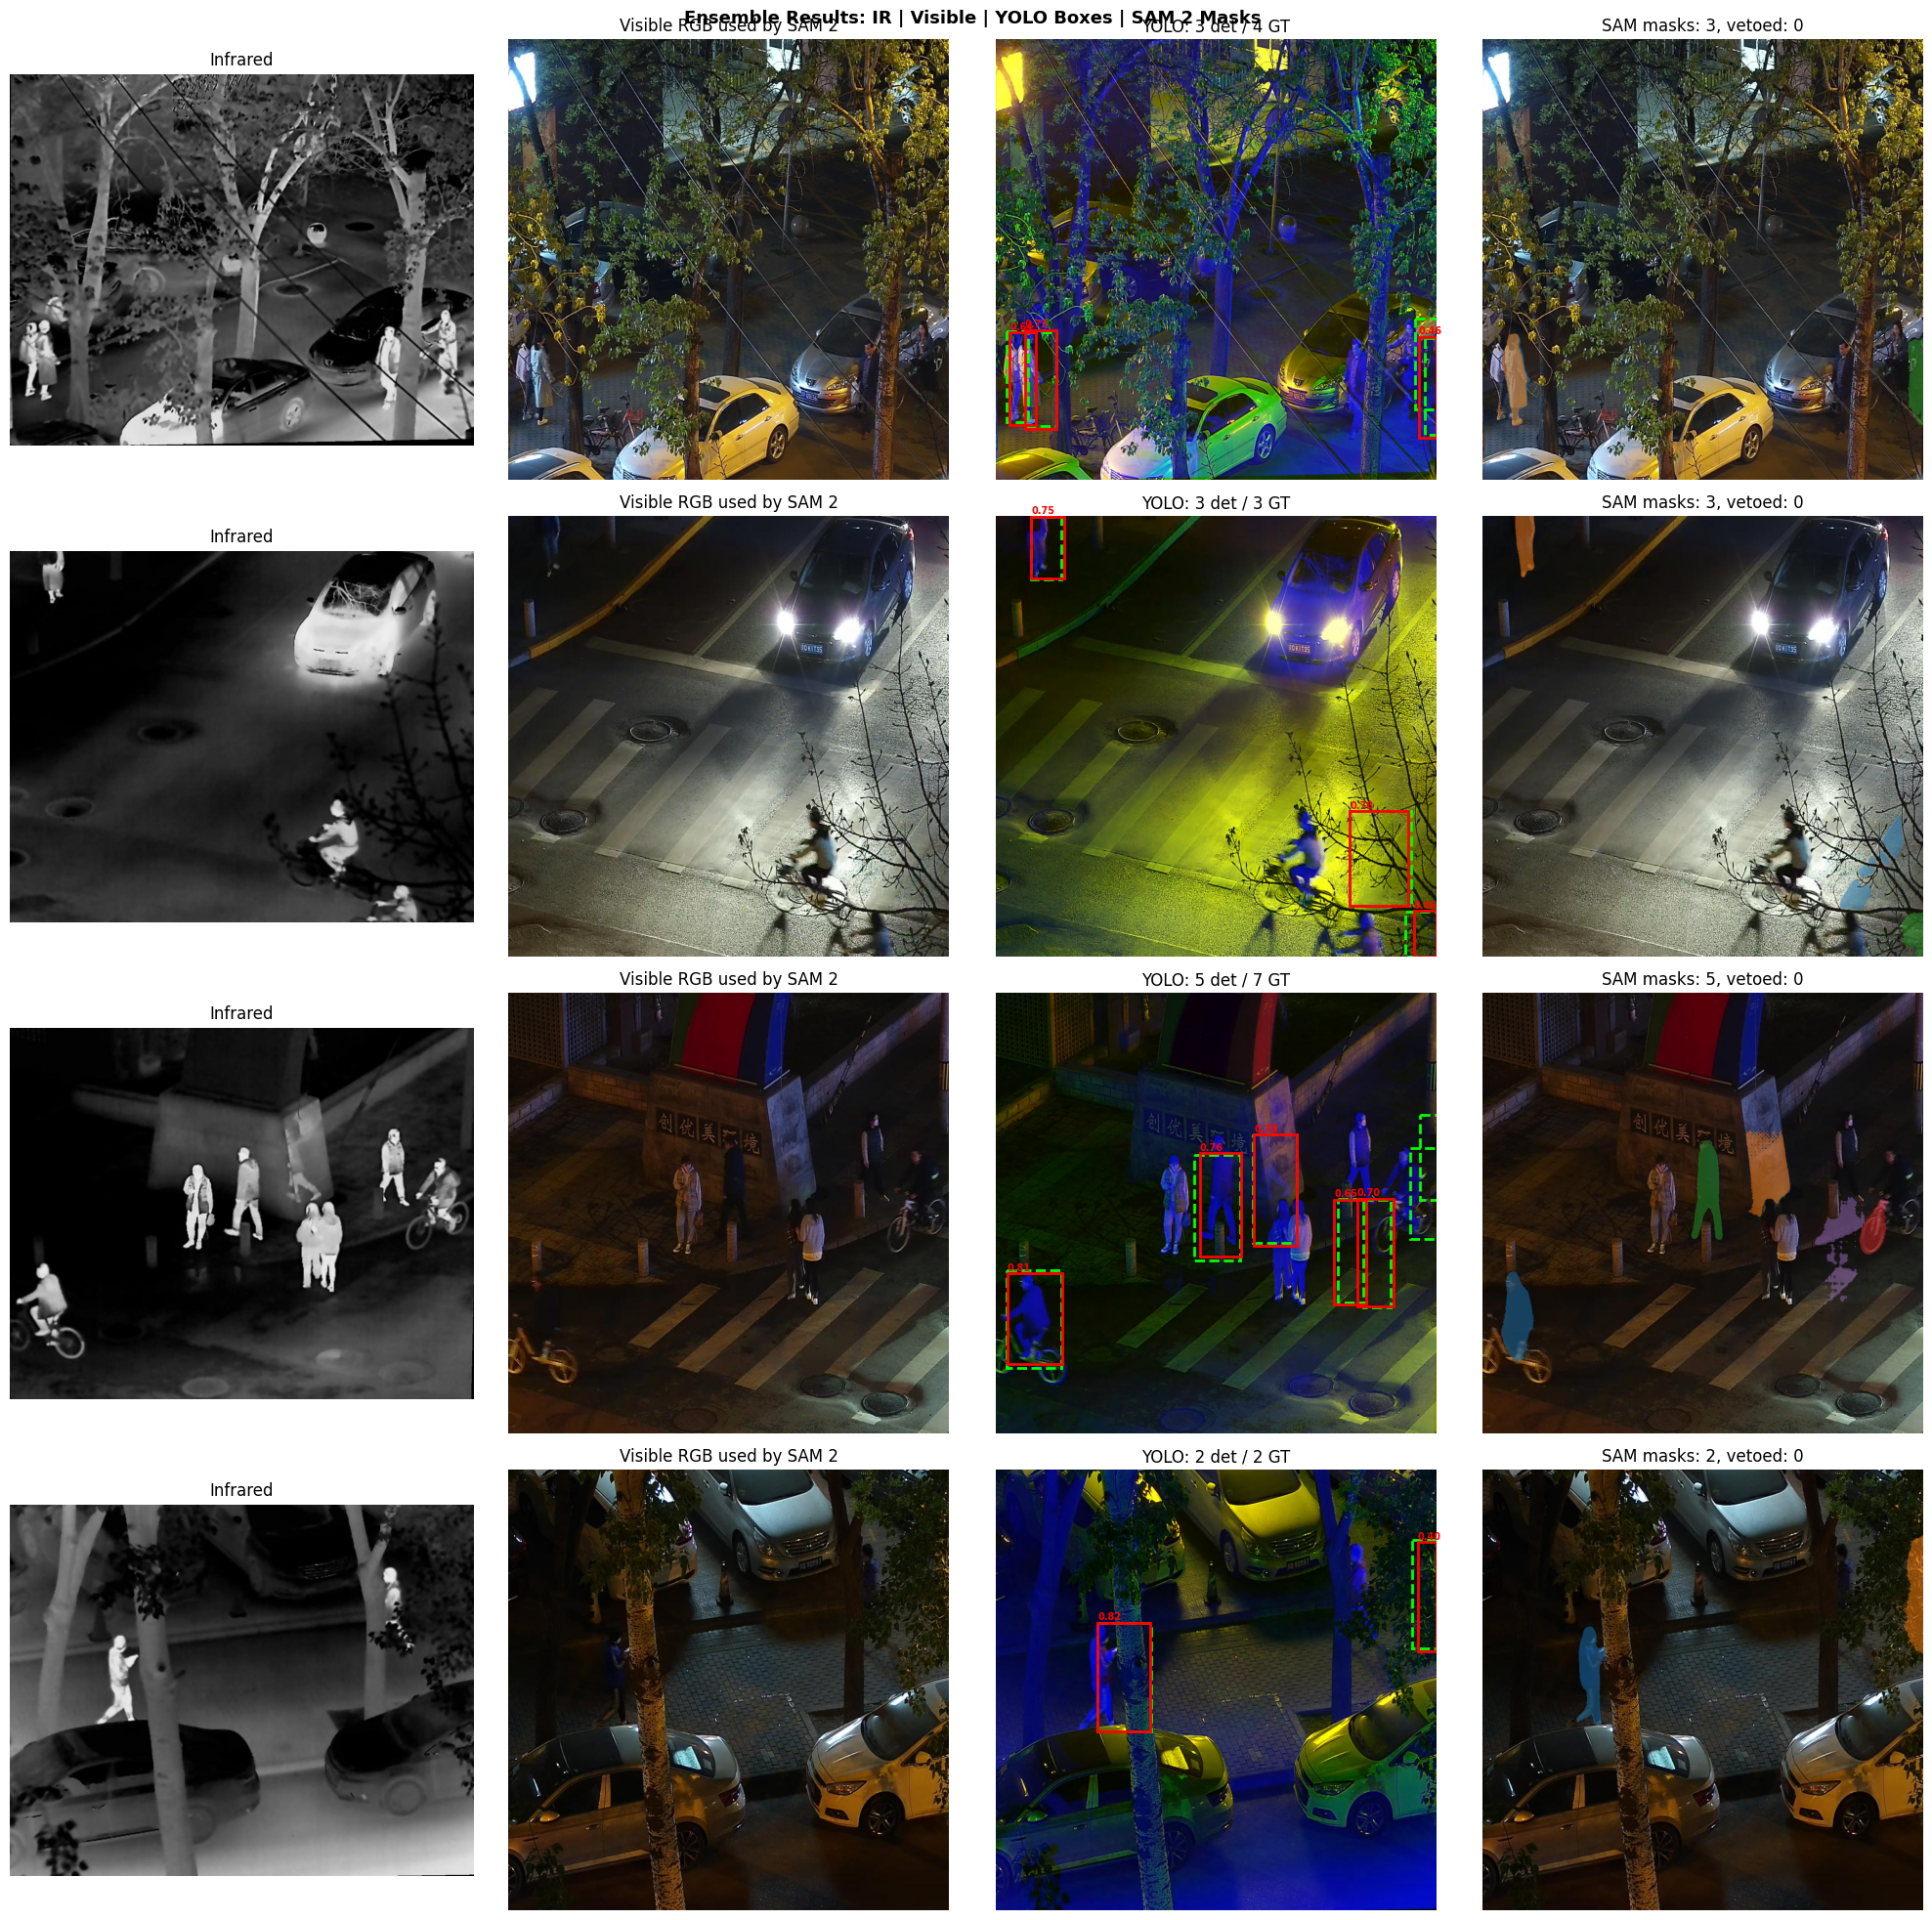

Saved ensemble qualitative plot: /home/vteam5/multispectral_pedestrian_ensemble/results_ensemble_v2/ensemble_qualitative.png


In [ ]:
sample_indices = random.sample(range(len(all_results)), min(4, len(all_results)))
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(20, 5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes])
fig.suptitle("Ensemble Results: IR | Visible | YOLO Boxes | SAM 2 Masks", fontsize=13, fontweight="bold")
COLORS = plt.cm.tab10.colors

for row, idx in enumerate(sample_indices):
    res = all_results[idx]
    gt = load_gt(processed_dataset_dir / "val" / "labels" / (val_fused_paths[idx].stem + ".txt"), TARGET_RES)

    axes[row, 0].imshow(res["infrared_image"], cmap="gray")
    axes[row, 0].set_title("Infrared")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(res["visible_image"])
    axes[row, 1].set_title("Visible RGB used by SAM 2")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(res["fused_image"])
    for gb in gt:
        axes[row, 2].add_patch(patches.Rectangle((gb[0], gb[1]), gb[2]-gb[0], gb[3]-gb[1],
                               lw=2, edgecolor="lime", linestyle="--", facecolor="none"))
    for b, c in zip(res["yolo_boxes_xyxy"], res["yolo_conf"]):
        axes[row, 2].add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                               lw=2, edgecolor="red", facecolor="none"))
        axes[row, 2].text(b[0], b[1]-5, f"{c:.2f}", color="red", fontsize=7, fontweight="bold")
    axes[row, 2].set_title(f"YOLO: {len(res['yolo_boxes_xyxy'])} det / {len(gt)} GT")
    axes[row, 2].axis("off")

    overlay = res["visible_image"].copy()
    for mi, mask in enumerate(res["final_masks"]):
        color = np.array(COLORS[mi % len(COLORS)][:3]) * 255
        overlay[mask] = (overlay[mask] * 0.5 + color * 0.5).astype(np.uint8)
    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title(f"SAM masks: {len(res['final_masks'])}, vetoed: {res['vetoed']}")
    axes[row, 3].axis("off")

plt.tight_layout()
ensemble_plot_path = ensemble_results_dir / "ensemble_qualitative.png"
plt.savefig(ensemble_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved ensemble qualitative plot: {ensemble_plot_path}")


# SAM 2 Bridge Export (can be used in future projects)


In [ ]:
ensemble_export = {
    "metadata": {
        "checkpoint_path": str(best_checkpoint_path),
        "sam_input": "visible_rgb",
        "image_size": TARGET_RES,
        "confidence_threshold": cascade_conf,
        "mask_validation": veto_settings,
        "format": "boxes_xyxy_absolute_pixels",
        "num_images": len(all_results),
    },
    "results": {},
}

for res in all_results:
    ensemble_export["results"][res["image_name"]] = {
        "yolo_boxes_xyxy": np.asarray(res["yolo_boxes_xyxy"]).round(2).tolist(),
        "yolo_confidences": np.asarray(res["yolo_conf"]).round(4).tolist(),
        "sam_mask_boxes_xyxy": np.asarray(res["final_mask_boxes_xyxy"]).round(2).tolist(),
        "sam_scores": np.asarray(res["final_scores"]).round(4).tolist(),
        "vetoed": res["vetoed"],
        "veto_reasons": res["veto_reasons"],
    }

ensemble_bridge_path = ensemble_results_dir / "ensemble_bridge_results.json"
with open(ensemble_bridge_path, "w") as f:
    json.dump(ensemble_export, f, indent=2)
print(f"Saved ensemble bridge file: {ensemble_bridge_path}")


Saved ensemble bridge file: /home/vteam5/multispectral_pedestrian_ensemble/results_ensemble_v2/ensemble_bridge_results.json


# Final Summary


In [ ]:
print("Multispectral pedestrian project summary")
print(f"Model: {yolo_model}")
print(f"Checkpoint: {best_checkpoint_path}")
print(f"Image size: {img_size}")
print(f"YOLO validation confidence: {conf_default}")
print(f"Cascade confidence: {cascade_conf}")
print(f"YOLO mAP@50: {map50:.4f}")
print(f"YOLO mAP@50-95: {map50_95:.4f}")
print(f"YOLO validation precision: {precision:.4f}")
print(f"YOLO validation recall: {recall:.4f}")
print(f"Head-to-head YOLO F1@50: {yf:.4f}")
print(f"Head-to-head ensemble F1@50: {ef:.4f}")
print(f"Ensemble proxy mIoU: {proxy_miou:.4f}")
print(f"Veto rate: {veto_rate:.1f}%")

print("Saved artifacts")
for folder in [detection_results_dir, ensemble_results_dir]:
    print(f"Folder: {folder}")
    for p in sorted(folder.rglob("*")):
        if p.is_file() and p.suffix in (".csv", ".json", ".png", ".pt"):
            print(f"  {p.relative_to(folder)} ({p.stat().st_size/1e6:.2f} MB)")

Multispectral pedestrian project summary
Model: yolo11s.pt
Checkpoint: /home/vteam5/multispectral_pedestrian_ensemble/results/pedestrian_multispectral_yolo11s/weights/best.pt
Image size: 1024
YOLO validation confidence: 0.25
Cascade confidence: 0.3
YOLO mAP@50: 0.8805
YOLO mAP@50-95: 0.4449
YOLO validation precision: 0.9268
YOLO validation recall: 0.8877
Head-to-head YOLO F1@50: 0.7636
Head-to-head ensemble F1@50: 0.7531
Ensemble proxy mIoU: 0.5738
Veto rate: 3.9%
Saved artifacts
Folder: /home/vteam5/multispectral_pedestrian_ensemble/results_detection
  confidence_sweep.csv (0.00 MB)
  confidence_sweep.png (0.08 MB)
  qualitative_samples.png (5.54 MB)
  training_curves.png (0.16 MB)
  yolo_baseline_metrics.json (0.00 MB)
  yolo_detections.json (1.00 MB)
Folder: /home/vteam5/multispectral_pedestrian_ensemble/results_ensemble_v2
  ensemble_bridge_results.json (1.53 MB)
  ensemble_metrics.json (0.00 MB)
  ensemble_per_image_metrics.csv (0.06 MB)
  ensemble_qualitative.png (7.55 MB)
  ense